# Intro

**Terminology**

$$ r \text{ or } rank(A)$$

* a non-negative integer

**Maximum possible rank**

$$ max(r) = min(m,n) $$

where:

* $m$ - number of rows
* $n$ - number of columns

so rank is number of rows or columns of a matrix whatever is smaller.

$$ r \in \mathbb{N}, s.t. 0 \leq r \leq min {m,n} $$

**Rank names**

* $$rank\underset{m\, \times\, m}{(A)} = m \rightarrow \text{Full rank matrix}$$
* $$rank\underset{m\,>\, n}{(A)} = n \rightarrow \text{Full column rank}$$
* $$rank\underset{m\,<\, n}{(A)} = m \rightarrow \text{Full row rank}$$

* $$rank\underset{m\,<\, n}{(A)} < m,n \rightarrow \text{Reduced rankm Rank deficient, Degenerate, Low-rank, Singular}$$

* $$ rab $$

**Matrix Rank**

Here we have rank = 2, because 2d.

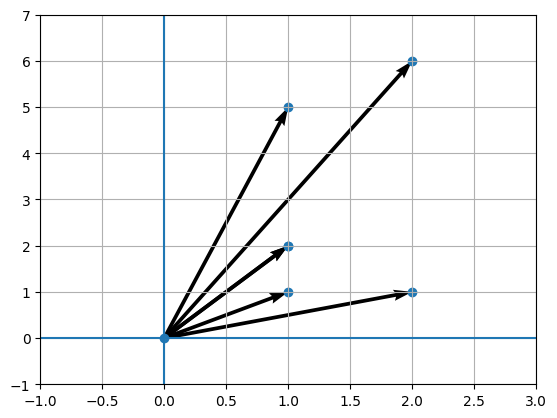

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [1,1,0,1,2,1,2],
    [2,1,0,5,6,2,1]
])

x = A[0]
y = A[1]

plt.quiver(
    np.zeros_like(x),
    np.zeros_like(y),  # starty wektorów: (0,0)
    x, y,                               # końce/kierunki: (x,y)
    angles='xy',
    scale_units='xy',
    scale=1
)

plt.scatter(x, y)
plt.xlim(-1, 3)
plt.ylim(-1, 7)
plt.grid(True)
plt.axhline(0)
plt.axvline(0)
plt.show()

The rank of a matrix is the largest number of columns (or rows) that can form a linearly independent set.

Rank is the number of dimensions of information

Rank is the number of columns that form a linearly independent set, so not in same dimension. Always when we have e.g. 2x10 so 10 columns with 2 rows each, we have just rank 2, because all vectors with 2 datapoints (rows) can be spanned only in 2d, we simply can't do 3d.

# Computing Rank

* Several methods to compute matrix rank
* Understand why computing rnak in real datasets is not as easy as it is in an introductiory linear algebra course

## Methods

**Count the number of columns in a linearly independent set**

  a) By visual inspection and a bit of guesswork

  b) By applying methods used to solve systems of simultaneous linear equations

**Apply row reduction to reduce matrix to echelon form**

**Compute the singular value decomposition and count the number of non-zero singular values**

**Compute the eigendecomposition and count the number of non-zero eigenvalues**

In [ ]:
# make a matrix
m = 6
n = 4

# create a random matrix
A = np.random.randn(m,n)

# what is the largest possible rank?
ra = np.linalg.matrix_rank(A)
print('rank = ' + str(ra))

# set last column to be repeat of penultimate column
B = A
B[:,-1] = B[:,-2]
print(B)

rb = np.linalg.matrix_rank(B)
print('rank = ' + str(rb))

rank = 4
[[ 0.68139081  1.10491643  0.24930781  0.24930781]
 [ 1.84314229 -0.53810798 -1.04454627 -1.04454627]
 [ 0.14188416  0.48874375  0.9484247   0.9484247 ]
 [ 1.83817269  1.24425387 -0.71526663 -0.71526663]
 [ 1.37192106 -0.12686313 -1.09583744 -1.09583744]
 [ 0.42208187 -0.179085   -0.71928981 -0.71928981]]
rank = 3


Duplicating rows or columns (whatever is smaller in count) will cause reduce in rank, then duplicating whatever has higher count wont cause reduce in rank.

In [ ]:
# adding noise to a rank-deficient matrix

# square for convenience
A = np.round(10 * np.random.randn(m, m))

# reduce the rank
A[:, -1] = A[:, -2]

# noise level
noisemp = 1e-12 # 1e-13

# add the noise
B = A + noisemp * np.random.randn(m,m)

print('rank (w/o noise) = ' + str(np.linalg.matrix_rank(A)))
print('rank (with noise) = ' + str(np.linalg.matrix_rank(B)))

rank (w/o noise) = 5
rank (with noise) = 6


1e-13 noise causes that there is no additional noise, everything less precise adds 1 to rank.

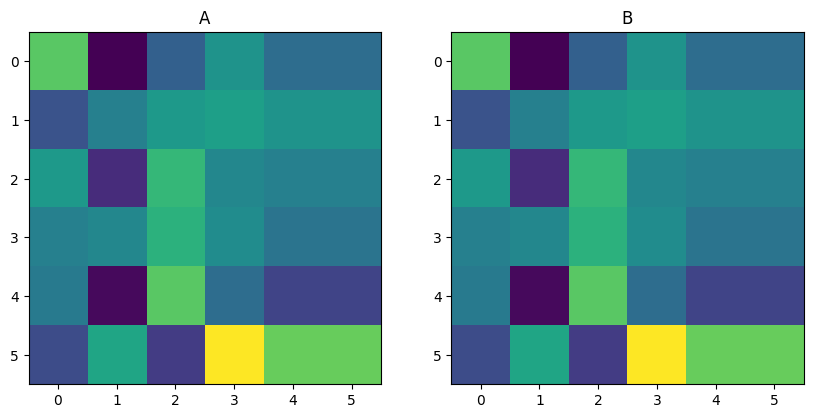

In [ ]:
_, axs = plt.subplots(1,2,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

plt.show()

# Rank of added and multiplied matriced

## Added

$$ rank(A + B) \leq rank(A) + rank(B) $$

* Know the limits of rank(A+B) and rank(AB)

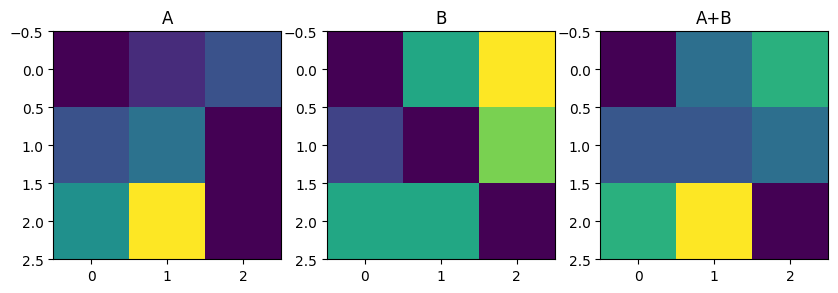


A rank:   3
B rank:   3
sum rank: 3


In [ ]:
A = np.array([[1,2,3],[3,4,1],[5,9,1]])
B = np.array([[0,3,5],[1,0,4],[3,3,0]])

_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

axs[2].imshow(A+B)
axs[2].set_title('A+B')

plt.show()


A_rank = np.linalg.matrix_rank(A)
B_rank = np.linalg.matrix_rank(B)
sum_rank = np.linalg.matrix_rank(A+B)

print(f'\nA rank:   {A_rank}\nB rank:   {B_rank}\nsum rank: {sum_rank}')

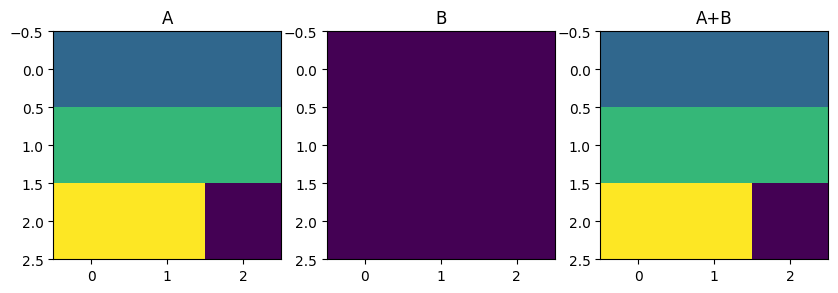


A rank:   2
B rank:   0
sum rank: 2


In [ ]:
A = np.array([[1,1,1],[2,2,2],[3,3,0]])
B = np.zeros((3,3))

_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

axs[2].imshow(A+B)
axs[2].set_title('A+B')

plt.show()


A_rank = np.linalg.matrix_rank(A)
B_rank = np.linalg.matrix_rank(B)
sum_rank = np.linalg.matrix_rank(A+B)

print(f'\nA rank:   {A_rank}\nB rank:   {B_rank}\nsum rank: {sum_rank}')

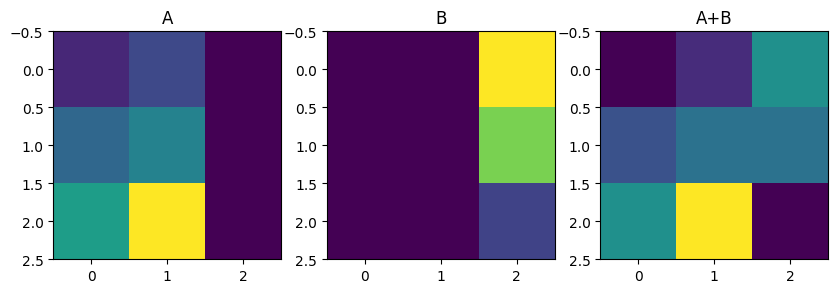


A rank:   2
B rank:   1
sum rank: 3


In [ ]:
A = np.array([[1,2,0],[3,4,0],[5,9,0]])
B = np.array([[0,0,5],[0,0,4],[0,0,1]])

_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

axs[2].imshow(A+B)
axs[2].set_title('A+B')

plt.show()

A_rank = np.linalg.matrix_rank(A)
B_rank = np.linalg.matrix_rank(B)
sum_rank = np.linalg.matrix_rank(A+B)

print(f'\nA rank:   {A_rank}\nB rank:   {B_rank}\nsum rank: {sum_rank}')

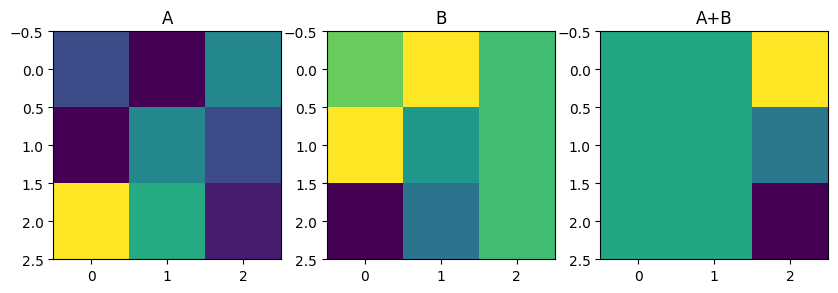


A rank:   3
B rank:   2
sum rank: 1


In [ ]:
A = np.array([[-1,-4,2],[-4,2,-1],[9,4,-3]])
B = np.array([[1,4,0],[4,-2,0],[-9,-4,0]])

_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

axs[2].imshow(A+B)
axs[2].set_title('A+B')

plt.show()

A_rank = np.linalg.matrix_rank(A)
B_rank = np.linalg.matrix_rank(B)
sum_rank = np.linalg.matrix_rank(A+B)

print(f'\nA rank:   {A_rank}\nB rank:   {B_rank}\nsum rank: {sum_rank}')

## Multiplied

$$ rank(AB) \leq min\{ rank(A), rank(B) \} $$

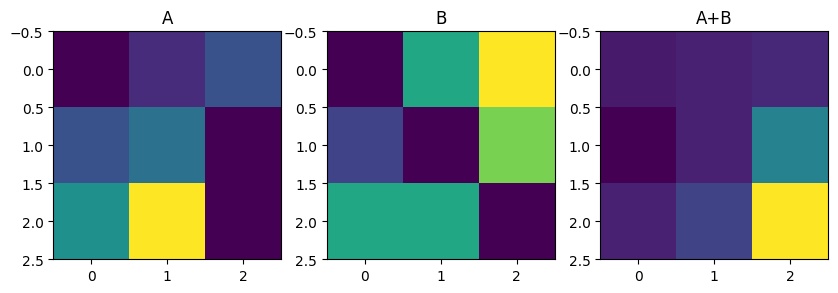


A rank:   3
B rank:   3
sum rank: 3


In [ ]:
A = np.array([[1,2,3],[3,4,1],[5,9,1]])
B = np.array([[0,3,5],[1,0,4],[3,3,0]])

_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

axs[2].imshow(A@B)
axs[2].set_title('A+B')

plt.show()


A_rank = np.linalg.matrix_rank(A)
B_rank = np.linalg.matrix_rank(B)
sum_rank = np.linalg.matrix_rank(A@B)

print(f'\nA rank:   {A_rank}\nB rank:   {B_rank}\nsum rank: {sum_rank}')

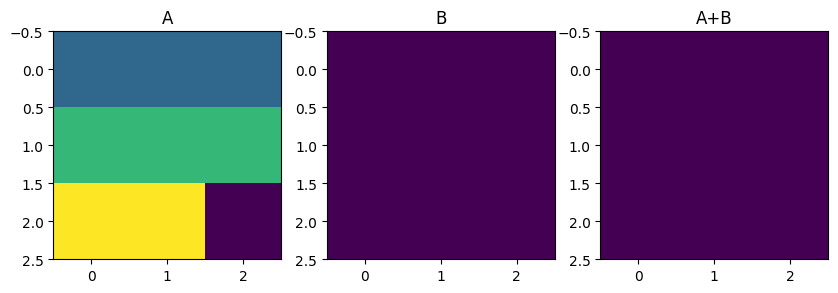


A rank:   2
B rank:   0
sum rank: 0


In [ ]:
A = np.array([[1,1,1],[2,2,2],[3,3,0]])
B = np.zeros((3,3))

_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

axs[2].imshow(A@B)
axs[2].set_title('A+B')

plt.show()


A_rank = np.linalg.matrix_rank(A)
B_rank = np.linalg.matrix_rank(B)
sum_rank = np.linalg.matrix_rank(A@B)

print(f'\nA rank:   {A_rank}\nB rank:   {B_rank}\nsum rank: {sum_rank}')

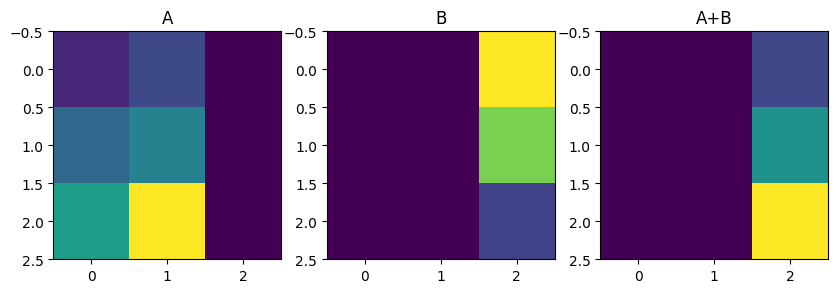


A rank:   2
B rank:   1
sum rank: 1


In [ ]:
A = np.array([[1,2,0],[3,4,0],[5,9,0]])
B = np.array([[0,0,5],[0,0,4],[0,0,1]])

_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

axs[2].imshow(A@B)
axs[2].set_title('A+B')

plt.show()

A_rank = np.linalg.matrix_rank(A)
B_rank = np.linalg.matrix_rank(B)
sum_rank = np.linalg.matrix_rank(A@B)

print(f'\nA rank:   {A_rank}\nB rank:   {B_rank}\nsum rank: {sum_rank}')

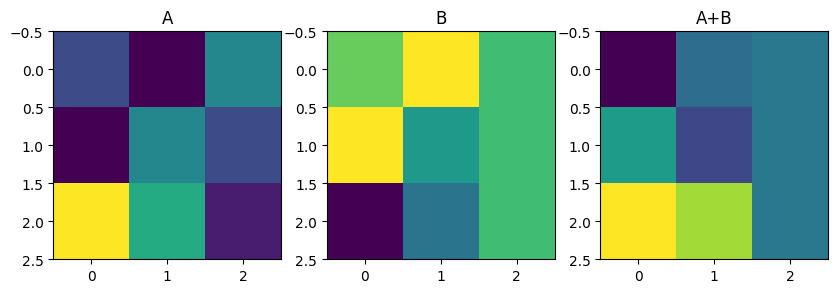


A rank:   3
B rank:   2
sum rank: 2


In [ ]:
A = np.array([[-1,-4,2],[-4,2,-1],[9,4,-3]])
B = np.array([[1,4,0],[4,-2,0],[-9,-4,0]])

_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(A)
axs[0].set_title('A')

axs[1].imshow(B)
axs[1].set_title('B')

axs[2].imshow(A@B)
axs[2].set_title('A+B')

plt.show()

A_rank = np.linalg.matrix_rank(A)
B_rank = np.linalg.matrix_rank(B)
sum_rank = np.linalg.matrix_rank(A@B)

print(f'\nA rank:   {A_rank}\nB rank:   {B_rank}\nsum rank: {sum_rank}')

# Reduced-rank matrix using multiplication

In [ ]:
# goal: create reduced-rank matrix using multiplication

# use matrix multiplication to create a 10x10 rank-4 matrix
A = np.random.randn(10, 4)
B = np.random.randn(4, 10)
C = A@B

print(np.shape(C))
print(np.linalg.matrix_rank(C))

# generalize to mxn rank-r
m = 8
n = 47
r = 3

A = np.random.randn(m,r) @ np.random.randn(r,n)
print(np.shape(A))
print(np.linalg.matrix_rank(A))

(10, 10)
4
(8, 47)
3


# Rank of $A^TA$ and $AA^T$

$$ rank(A) = rank(A^TA) = rank(A^T) = rank(AA^T)$$

# Making a matrix full-rank by "shifting"

$$ \widetilde{A} = A + \lambda I$$



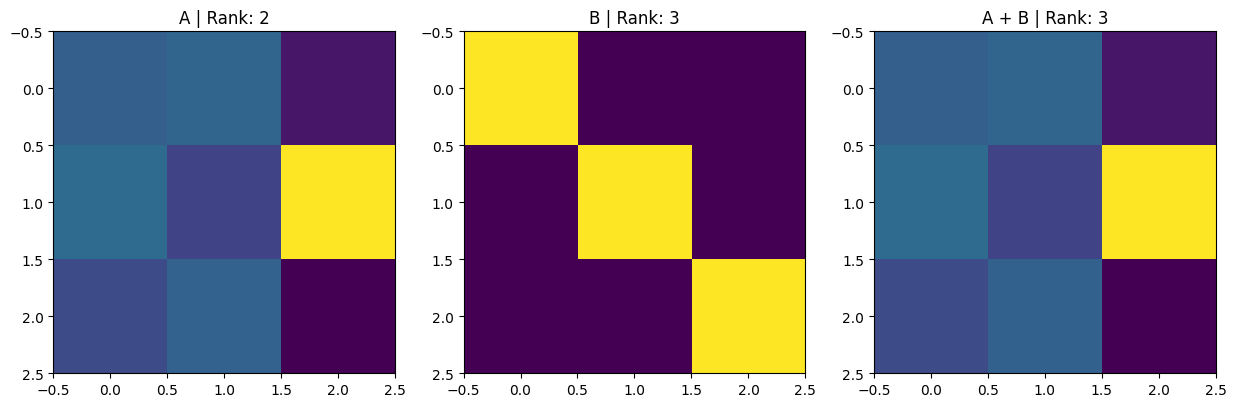

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([[1,3,-19],[5,-7,59],[-5,2,-24]])
b = 0.1 * np.eye(3)

_, axs = plt.subplots(1,3,figsize = (15,5))

axs[0].imshow(a)
axs[0].set_title(f'A | Rank: {np.linalg.matrix_rank(a)}')

axs[1].imshow(b)
axs[1].set_title(f'B | Rank: {np.linalg.matrix_rank(b)}')

axs[2].imshow(a + b)
axs[2].set_title(f'A + B | Rank: {np.linalg.matrix_rank(a+b)}')

plt.show()

By adding scaled identity matrix, we can't scale any column by 2 other columns, i.e. this operation increases rank, making in this case full rank matrix.

Text(0.5, 1.0, 'Rank: 30')

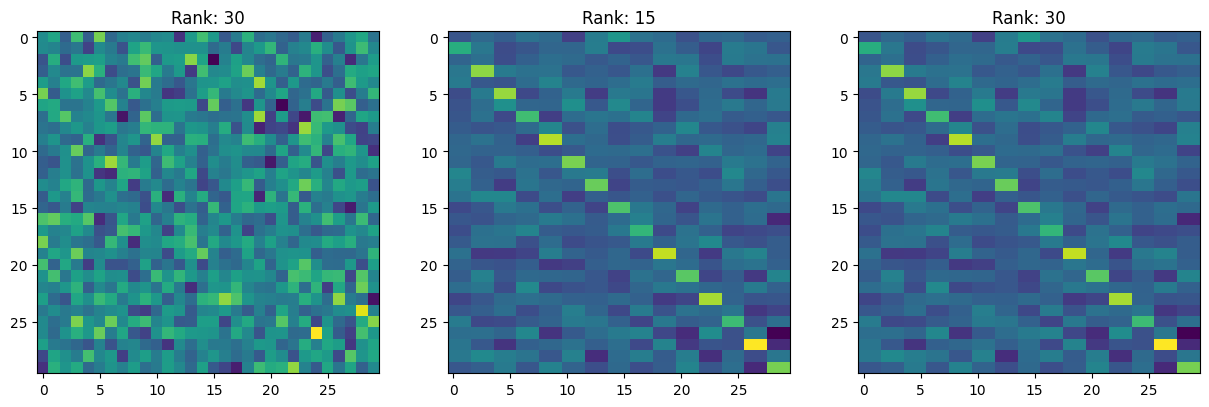

In [ ]:
# size of matrix
m = 30

# create the square symmetrix matrix
A = np.random.randn(m,m)
_, axs = plt.subplots(1,3,figsize = (15,5))
axs[0].imshow(A)
axs[0].set_title(f'Rank: {np.linalg.matrix_rank(A)}')


A = np.round(10*A.T@A)
# reduce the rank
for i in range(0,30,2):
  A[:,i] = A[:,i+1]

# A = np.zeros((m,m))

axs[1].imshow(A)
axs[1].set_title(f'Rank: {np.linalg.matrix_rank(A)}')

# shift amount (l = lambda)
l = .01
# new matrix
B = A + l * np.eye(m,m)
# print information
axs[2].imshow(B)
axs[2].set_title(f'Rank: {np.linalg.matrix_rank(B)}')

We can make any rank reduction (even to rank 0) and after operation $A + \lambda I$ we always get full rank matrix

# Span by Rank

Check if v is in the span of S or T

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

v = np.array([[1,2,3,4]]).T

S = np.array([[4,3,6,2], [0,4,0,1]]).T
T = np.array([[1,2,2,2], [0,0,1,2]]).T

In [ ]:
S_ = np.hstack([S, v])
print(f'S  rank: {np.linalg.matrix_rank(S)}')
print(f'S_ rank: {np.linalg.matrix_rank(S_)}')

S  rank: 2
S_ rank: 3


v is not in the span of S since it increases rank of S.

In [ ]:
T_ = np.hstack([T, v])
print(f'T  rank: {np.linalg.matrix_rank(T)}')
print(f'T_ rank: {np.linalg.matrix_rank(T_)}')

T  rank: 2
T_ rank: 2


v is in the span of T since it doesn't increase the rank of T.

*Based on a notebook of Mike X Cohen. Notebook was modified.*